# Multi-Hop Chain-of-Thought RAG Evaluation

This notebook runs the RAG evaluation on our custom `eval_hotpot_nutrition.jsonl` dataset, which evaluates the **Multi-Hop Chain-of-Thought** reasoning capabilities of the system. It runs the evaluation, extracts summary statistics, displays the detailed question-by-question metrics, and generates visual charts for report documentation.

In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get initial working directory (notebook's directory)
initial_dir = os.getcwd()

# Safe change of working directory to project root
if "notebooks" in initial_dir:
    repo_root = os.path.abspath(os.path.join(initial_dir, "../.."))
    os.chdir(repo_root)
else:
    repo_root = initial_dir

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print(f"Project root: {repo_root}")
print(f"Current working directory of kernel: {os.getcwd()}")

from src.evaluation.rag_evaluator import run_evaluation

Project root: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG
Current working directory of kernel: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG


## 1. Run Evaluation
We run the evaluation pipeline in `full` mode (routing + retrieval + generation) on the 5 custom multi-hop cases.

In [2]:
input_path = os.path.join(repo_root, "data/en/eval_hotpot_nutrition.jsonl")
output_dir = os.path.join(repo_root, "reports/en/rag_eval_hotpot")
config_path = os.path.join(repo_root, "configs/config.yaml")
corpus_path = os.path.join(repo_root, "data/en/corpus.jsonl")

print("Running evaluation (this may take 1-2 minutes depending on local Ollama inference speed)... ")
summary = run_evaluation(
    input_path=input_path,
    output_dir=output_dir,
    config_path=config_path,
    corpus_path=corpus_path,
    top_k=20,
    mode="full"
)
print("\nEvaluation successfully finished!")

Running evaluation (this may take 1-2 minutes depending on local Ollama inference speed)... 


d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Running full evaluation on 71 record(s)...
  [1/71] Is Hibiscus sabdariffa helpful in lowering cholesterol for metabolic syndrome pa



[DEBUG PROMPT] Final Injected Prompt Sent to LLM:
You are a professional nutrition and health assistant. Answer DIRECTLY in English, in a natural, conversational, and helpful manner.
Do NOT mention any rules, instructions, system prompts, or formatting/structural constraints to the user. Do NOT say 'I will follow the new structure' or make similar meta-comments. Always remain in character.
All questions are asked by a human user regarding human nutrition, diet, and health. Do NOT interpret queries as being about live animals, livestock, or veterinary care. Any food terms mentioned (like 'chicken', 'a chicken with garlic', etc.) refer to human foods/dishes, not a live animal.
When reasoning about glycemic index (GI), blood sugar, or diabetes, base your answer on actual carbohydrate content. Foods with 0g of carbohydrate (like lean beef or chicken breast) have a Glycemic Index of essentially zero and do not raise blood sugar levels. Never claim that zero-carb meats are 'relatively high-

## 2. Display Evaluation Summary

In [3]:
print("--- EVALUATION SUMMARY METRICS ---")
print(json.dumps(summary["metrics"], indent=4))

--- EVALUATION SUMMARY METRICS ---
{
    "avg_latency_sec": 7.4155,
    "intent_accuracy": 0.4789,
    "retrieval_hit_rate": 0.9437,
    "retrieval_recall_at_k": 0.9401,
    "retrieval_precision_at_k": 0.0655,
    "retrieval_mrr_at_k": 0.9545,
    "answer_exact_match_rate": 0.0,
    "answer_token_f1": 0.1652,
    "answer_keyword_hit_rate": 1.0,
    "source_keyword_hit_rate": 0.0
}


## 3. Display Question-by-Question Detailed Results

In [4]:
cases_df = pd.read_csv(os.path.join(output_dir, "cases.csv"))
pd.set_option('display.max_colwidth', 150)
cases_df[["question", "predicted_intent", "intent_correct", "latency_sec", "answer_keyword_hit"]]

,question,predicted_intent,intent_correct,latency_sec,answer_keyword_hit
0,Is Hibiscus sabdariffa helpful in lowering cholesterol for metabolic syndrome patients?,HEALTH_ADVICE,False,39.2585,True
1,Can ginger help alleviate nausea and vomiting during pregnancy?,HEALTH_ADVICE,False,6.6462,True
2,Does drinking grapefruit juice affect cardiovascular health and cause drug interactions?,HEALTH_ADVICE,False,8.7148,True
3,Does consumption of cooking oil and fish oil capsules affect octylphenol concentrations in breast milk?,HEALTH_ADVICE,False,6.8290,True
4,How does dietary phosphorus or phosphate additives in grain products affect cardiovascular health?,HEALTH_ADVICE,False,8.1090,True
...,...,...,...,...,...
66,Can cyanotoxins in the environment cause ALS or neurodegenerative disease?,HEALTH_ADVICE,True,7.9855,True
67,Is yeast beta-glucan effective for preventing common colds?,HEALTH_ADVICE,False,6.4241,True
68,Can whole grain consumption help prevent type 2 diabetes and body weight gain?,HEALTH_ADVICE,False,7.1625,True
69,Are organic foods substantially more nutritious than conventional foods?,HEALTH_ADVICE,False,9.4450,True


## 4. Plot Metrics Visualizations
We generate two charts: one comparing system percentages (intent correctness, recall, precision, keyword hit rate) and one plotting latency per question.

C:\Users\dongb\AppData\Local\Temp\ipykernel_26616\2015994156.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Score", y="Metric", data=df_pct, palette="viridis")


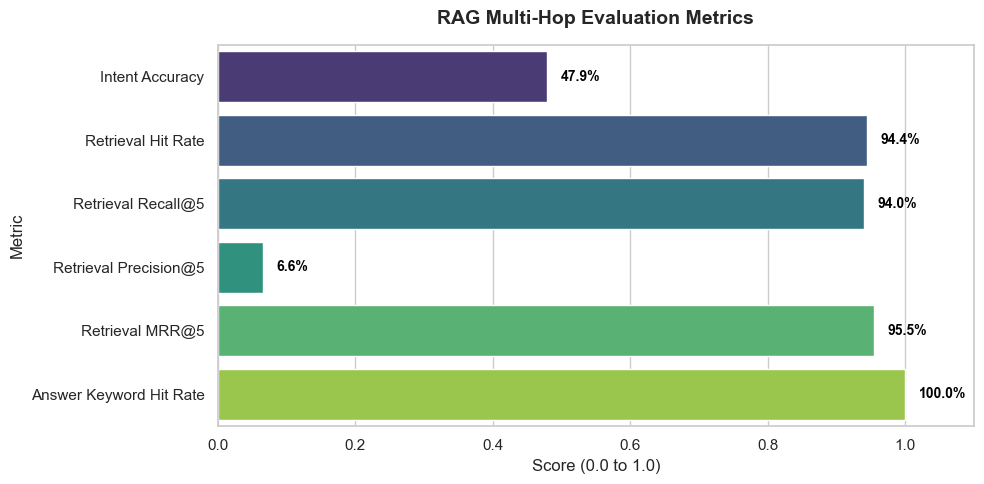

Saved metrics chart to: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\reports/en/rag_eval_hotpot\metrics_chart.png


In [5]:
# Plot 1: Percentage Metrics Chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

metrics_dict = summary["metrics"]
pct_metrics = {
    "Intent Accuracy": metrics_dict.get("intent_accuracy", 0),
    "Retrieval Hit Rate": metrics_dict.get("retrieval_hit_rate", 0),
    "Retrieval Recall@5": metrics_dict.get("retrieval_recall_at_k", 0),
    "Retrieval Precision@5": metrics_dict.get("retrieval_precision_at_k", 0),
    "Retrieval MRR@5": metrics_dict.get("retrieval_mrr_at_k", 0),
    "Answer Keyword Hit Rate": metrics_dict.get("answer_keyword_hit_rate", 0)
}

df_pct = pd.DataFrame(list(pct_metrics.items()), columns=["Metric", "Score"])

ax = sns.barplot(x="Score", y="Metric", data=df_pct, palette="viridis")
plt.xlim(0.0, 1.1)
plt.title("RAG Multi-Hop Evaluation Metrics", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Score (0.0 to 1.0)", fontsize=12)
plt.ylabel("Metric", fontsize=12)

# Add data label percentages on top of the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.02, p.get_y() + p.get_height()/2, f"{width:.1%}", 
             va="center", ha="left", fontsize=10, color="black", fontweight="bold")

chart_1_path = os.path.join(output_dir, "metrics_chart.png")
plt.tight_layout()
plt.savefig(chart_1_path, dpi=300)
plt.show()
print(f"Saved metrics chart to: {chart_1_path}")

C:\Users\dongb\AppData\Local\Temp\ipykernel_26616\1317682177.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_lat = sns.barplot(x=cases_df.index + 1, y="latency_sec", data=cases_df, palette="magma")


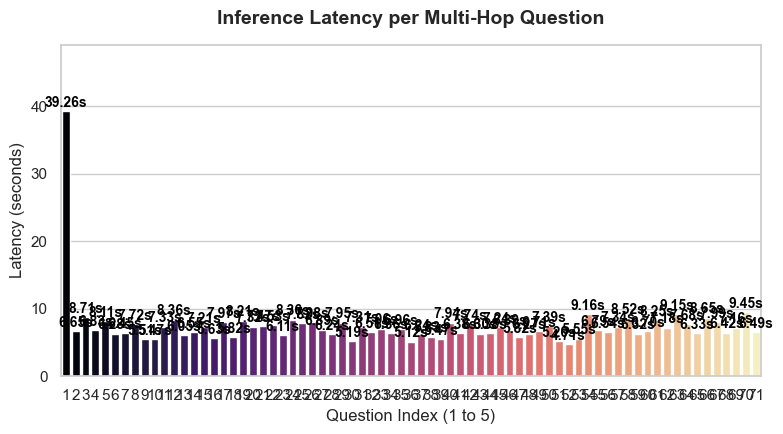

Saved latency chart to: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\reports/en/rag_eval_hotpot\latency_chart.png


In [6]:
# Plot 2: Latency Distribution Chart
plt.figure(figsize=(8, 4.5))

ax_lat = sns.barplot(x=cases_df.index + 1, y="latency_sec", data=cases_df, palette="magma")
plt.title("Inference Latency per Multi-Hop Question", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Question Index (1 to 5)", fontsize=12)
plt.ylabel("Latency (seconds)", fontsize=12)
plt.ylim(0, cases_df["latency_sec"].max() * 1.25)

# Annotate heights
for p in ax_lat.patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2., height + 0.2, f"{height:.2f}s", 
             ha="center", va="bottom", fontsize=10, color="black", fontweight="bold")

chart_2_path = os.path.join(output_dir, "latency_chart.png")
plt.tight_layout()
plt.savefig(chart_2_path, dpi=300)
plt.show()
print(f"Saved latency chart to: {chart_2_path}")